# Feature Occlusion for Explainable Forecasting

In this section, we apply feature occlusion to assess the relative importance of meteorological variables in the GraphCast prediction. This XAI method evaluates a model's sensitivity by selectively masking input features and measuring the resulting change in forecast accuracy.

A climatology-based baseline is used as the replacement value during occlusion. This requires a precomputed climatology, which provides typical values for each variable at the corresponding time and location.

Two occlusion strategries are considered:
- Single-variable occlusion:
    Each atmospheric or surface variable is occluded individually. Wind-related variables (u_component_of_wind, v_component_of_wind) are occluded jointly and treated as wind speed. This setup includes both atmospheric and surface variables.

- Grouped-feature occlusion:
    In a second analysis, groups of features across different regions and pressure levels are occluded, focusing on geopotential height and wind speed. This captures how localized perturbations at specific altitudes affect the model's output, revealing spatial and vertical dependencies in the learned forecast representation.

The resulting change in model performance indicates the influence of each occluded feature or group on the final prediction.

In [1]:
import xarray as xr

from pkg.feature_occlusion.forecast_with_mask import run_multiple_forecasts_with_mask
from pkg.plots.feature_occlusion_plots import plot_mean_wind_speed_comparison_feature_occlusion, plot_region_level_heatmap

In [2]:
input_path = "../data/graphcast_small/graphcast_small_zeynep_input/graphcast_ready_input_graphcast_small_zeynep_input.nc"
climatology_path = "../data/data_for_climatology/era5_1979-2015_0218_climatology.nc"

climatology = xr.open_dataset(climatology_path)
input = xr.open_dataset(input_path)

original_prediction_path = "../data/graphcast_small/graphcast_small_zeynep_prediction.nc"

/var/folders/xf/c7vr94fn3vn_s8b10cwsp87c0000gn/T/ipykernel_99711/1196890261.py:5: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  input = xr.open_dataset(input_path)


## Feature Occlusion for all Variables (Atmospheric + Surface)

### Run Feature Occlusion for All Variables

In [ ]:
variables = [
    "2m_temperature",
    ("10m_u_component_of_wind",
    "10m_v_component_of_wind"),
    "total_precipitation_6hr",
    "mean_sea_level_pressure",
    "temperature",
    ("u_component_of_wind",
    "v_component_of_wind"),
    "geopotential",
    "vertical_velocity",
    "specific_humidity",
]

run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/all_variables",
    variable_groups=variables
)

### Plot Results Variables

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:57: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  unmasked_ds = xr.open_dataset(input_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:73: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(path)
/Users/estakempf/Tech/Bachel

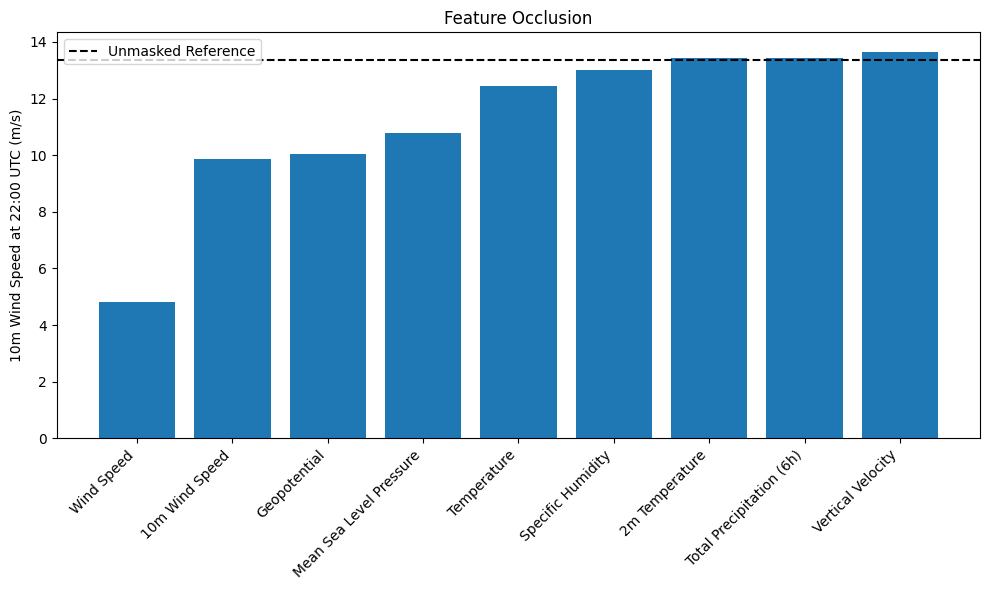

In [10]:
rename_map = {
    "2m_temperature_levnone_regnone_tnone": "2m Temperature",
    "mean_sea_level_pressure_levnone_regnone_tnone": "Mean Sea Level Pressure",
    "total_precipitation_6hr_levnone_regnone_tnone": "Total Precipitation (6h)",
    "('10m_u_component_of_wind', '10m_v_component_of_wind')_levnone_regnone_tnone": "10m Wind Speed",
    "temperature_levnone_regnone_tnone": "Temperature",
    "u_component_of_wind_levnone_regnone_tnone": "U Wind",
    "v_component_of_wind_levnone_regnone_tnone": "V Wind",
    "geopotential_levnone_regnone_tnone": "Geopotential",
    "vertical_velocity_levnone_regnone_tnone": "Vertical Velocity",
    "specific_humidity_levnone_regnone_tnone": "Specific Humidity",
    "('u_component_of_wind', 'v_component_of_wind')_levnone_regnone_tnone": "Wind Speed"
}

plot_mean_wind_speed_comparison_feature_occlusion(
    masked_folder="../data/feature_occlusion/all_variables",
    input_path=original_prediction_path,
    title = "Feature Occlusion",
    rename_map=rename_map,
    order_by_size=True
)

## Feature Occlusion for Different Regions and Pressure Level

In [ ]:
pressure_levels = [
    1000, 925, 850, 700, 600, 500, 400, 300, 250, 200, 150, 100, 50
]

regions = [
    "atlantic_jet_stream",
    "low_pressure_north",
    "storm_core",
    "dynamic_uljs" # Western European Jet Streak
]


### Run Combinations Geopotential

In [ ]:
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/geopotential_levels_regions",
    variable_groups=["geopotential"],
    regions=regions,
    pressure_levels=pressure_levels
)

# to include mean sea level pressure in the geopotential plots
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/geopotential_levels_regions",
    variable_groups=["mean_sea_level_pressure"],
)

### Run Combinations Wind Speed

In [ ]:
# run feature occlusion for wind speed
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/wind_levels_regions",
    variable_groups=[
        ("u_component_of_wind", "v_component_of_wind")
    ],
    regions=regions,
    pressure_levels=pressure_levels
)

# to include 10m wind speed 
run_multiple_forecasts_with_mask(
    input_data=input,
    climatology=climatology,
    predictions_folder="../data/feature_occlusion/wind_levels_regions",
    variable_groups=[("10m_u_component_of_wind", "10m_v_component_of_wind")]
)

### Plot Geopotential Heatmap

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:161: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:181: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:181: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_data

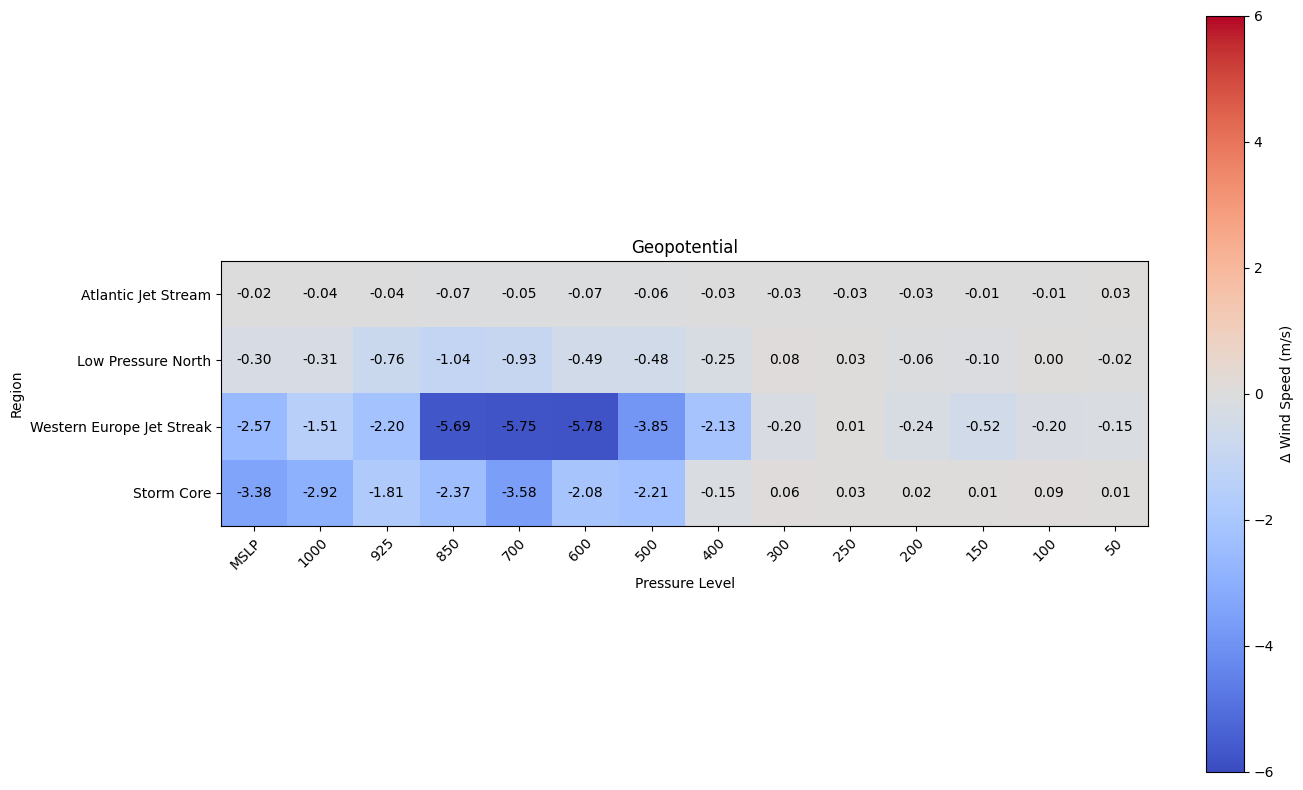

In [3]:
rename_map = {
    "none": "MSLP",  # Surface-level variable
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "dynamic_uljs_tnone": "Western Europe Jet Streak",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "storm_core_tnone": "Storm Core",
    "storm_region_tnone": "Storm Region",
    "north_germany": "North Germany"
}

level_order = ["MSLP", "1000", "925", "850", "700", "600", "500", "400", "300", "250", "200", "150", "100", "50"]

plot_region_level_heatmap(
    masked_folder="../data/feature_occlusion/geopotential_levels_regions",
    reference_path=original_prediction_path,
    title="Geopotential",
    rename_map=rename_map,
    level_order=level_order,
        region_order=[
        "Atlantic Jet Stream",
        "Low Pressure North",
        "Western Europe Jet Streak",
        "Storm Core",
    ]
)

### Plot Wind Speed Heatmap

/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:161: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  reference_ds = xr.open_dataset(reference_path)
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:181: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_dataset(os.path.join(masked_folder, fname))
/Users/estakempf/Tech/Bachelorarbeit/graphcast-xai/pkg/plots/feature_occlusion_plots.py:181: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds = xr.open_data

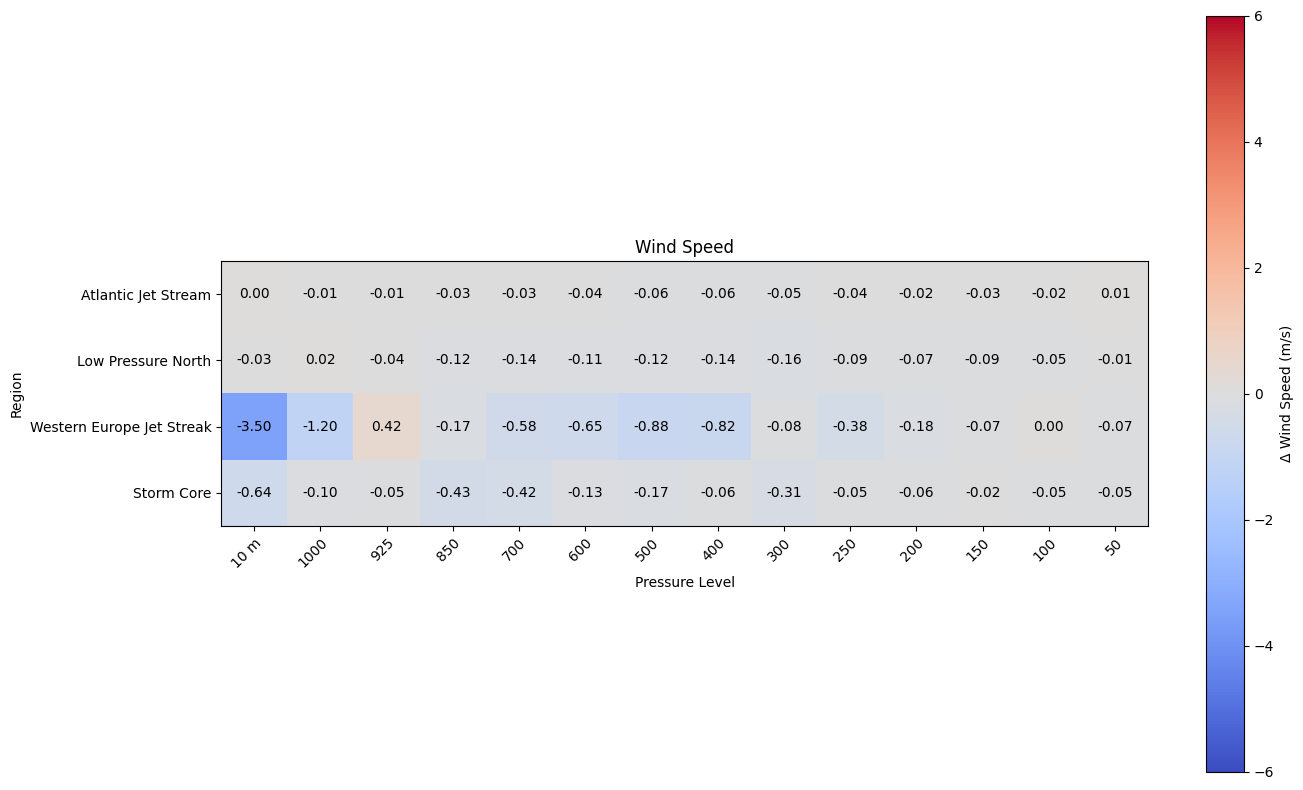

In [3]:
rename_map = {
    "none": "10 m",  # Surface-level variable
    "atlantic_jet_stream_tnone": "Atlantic Jet Stream",
    "dynamic_uljs_tnone": "Western Europe Jet Streak",
    "high_pressure_south_tnone": "High Pressure South",
    "low_pressure_north_tnone": "Low Pressure North",
    "storm_core_tnone": "Storm Core",
    "storm_region_tnone": "Storm Region",
    "north_germany": "North Germany"
}

level_order = ["10 m", "1000", "925", "850", "700", "600", "500", "400", "300", "250", "200", "150", "100", "50"]

plot_region_level_heatmap(
    masked_folder="../data/feature_occlusion/wind_levels_regions",
    reference_path=original_prediction_path,
    title="Wind Speed",
    rename_map=rename_map,
    level_order=level_order,
    region_order=[
        "Atlantic Jet Stream",
        "Low Pressure North",
        "Western Europe Jet Streak",
        "Storm Core",
    ]
)